# Walk-Forward Portfolio Optimization and Market Regime Analysis

### BRK-B | GLDM | QQQM | VOO

This project studies whether constrained Mean-Variance Optimization can
improve risk-adjusted portfolio performance and investigates the sources
of portfolio resilience across different VIX market regimes.

## Research Pipeline

Price Data
→ Return Estimation
→ Mean-Variance Optimization
→ Walk-Forward Backtesting
→ Robustness Testing
→ VIX Market Regime Analysis
→ Asset-Level Analysis
→ Return Attribution

In [1]:
import yfinance as yf

print("yfinance version:", yf.__version__)

test = yf.download(
    "VOO",
    period="1mo",
    progress=False
)

print(test.tail())

yfinance version: 1.7.0
Price            Close        High         Low        Open    Volume
Ticker             VOO         VOO         VOO         VOO       VOO
Date                                                                
2026-09-04  708.010010  710.450012  706.900024  709.719971   6806600
2026-09-08  704.070007  707.510010  703.369995  706.979980   7827600
2026-09-09  700.869995  702.710022  699.489990  702.349976   4293300
2026-09-10  696.650024  698.640015  695.539978  696.780029  18313400
2026-09-11  702.559998  704.500000  701.929993  703.000000   5792000


## 1. Data Collection and Return Estimation

Historical market prices are collected for four assets:

- **BRK-B** — Berkshire Hathaway
- **GLDM** — SPDR Gold MiniShares Trust
- **QQQM** — Invesco NASDAQ 100 ETF
- **VOO** — Vanguard S&P 500 ETF

Daily returns are calculated from price changes:

$$
R_t = \frac{P_t}{P_{t-1}} - 1
$$

where $P_t$ represents the asset price at time $t$.

The resulting return series form the foundation for the portfolio analysis.

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

assets = {
    "BRK-B": "Berkshire Hathaway",
    "GLDM": "SPDR Gold MiniShares",
    "VOO": "Vanguard S&P 500 ETF",
    "QQQM": "Invesco NASDAQ 100 ETF"
}

tickers = list(assets.keys())

data = yf.download(
    tickers,
    start="2018-01-01",
    progress=False,
    auto_adjust=True,
    threads=False
)["Close"]

print("Downloaded columns:")
print(data.columns)

print("\nFirst valid date:")
for ticker in data.columns:
    print(ticker, data[ticker].first_valid_index())

returns = np.log(data / data.shift(1)).dropna()

volatility = (
    returns
    .rolling(window=21)
    .std()
    * np.sqrt(252)
)

print("\nReturn data period:")
print(returns.index.min(), "to", returns.index.max())

print("\nNumber of observations:")
print(len(returns))

display(data.tail())

Downloaded columns:
Index(['BRK-B', 'GLDM', 'QQQM', 'VOO'], dtype='object', name='Ticker')

First valid date:
BRK-B 2018-01-02 00:00:00
GLDM 2018-06-26 00:00:00
QQQM 2020-10-13 00:00:00
VOO 2018-01-02 00:00:00

Return data period:
2020-10-14 00:00:00 to 2026-09-11 00:00:00

Number of observations:
1484


Ticker,BRK-B,GLDM,QQQM,VOO
Date,,,,
2026-09-04,506.029999,87.730003,296.070007,708.010010
2026-09-08,505.829987,86.230003,295.760010,704.070007
2026-09-09,506.720001,87.029999,294.970001,700.869995
2026-09-10,507.000000,85.510002,291.799988,696.650024
2026-09-11,510.369995,86.000000,294.390015,702.559998


## 2. Risk and Correlation Analysis

Before constructing the portfolio, the historical risk characteristics of the assets are examined.

Annualized volatility is estimated as:

$$
\sigma_{\text{annual}} = \sigma_{\text{daily}}\sqrt{252}
$$

The correlation matrix is also calculated to evaluate diversification potential between assets.

Lower correlations between assets may reduce overall portfolio risk through diversification.

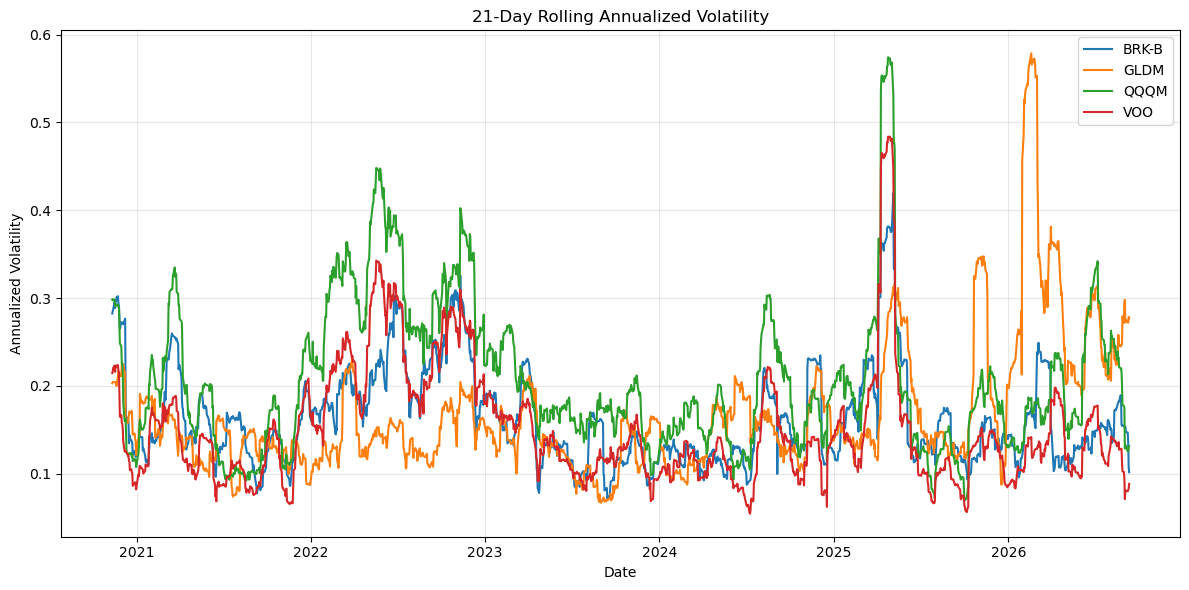

In [3]:
plt.figure(figsize=(12, 6))

for ticker in volatility.columns:
    plt.plot(
        volatility.index,
        volatility[ticker],
        label=ticker
    )

plt.title("21-Day Rolling Annualized Volatility")
plt.xlabel("Date")
plt.ylabel("Annualized Volatility")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Correlation and Diversification Analysis

Portfolio risk depends not only on the volatility of individual assets, but also on how their returns move relative to each other.

Correlation between two assets can be expressed as:

$$
\rho_{ij}
=
\frac{\operatorname{Cov}(R_i,R_j)}
{\sigma_i \sigma_j}
$$

A correlation close to +1 indicates that two assets tend to move together, while lower correlations suggest stronger diversification potential.

The correlation matrix is therefore used to evaluate whether combining the selected assets may reduce overall portfolio risk.

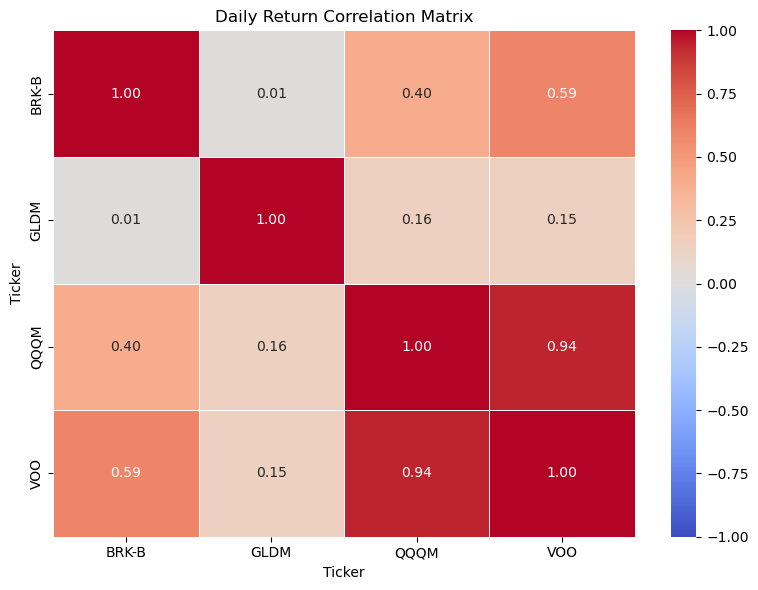

In [4]:
correlation_matrix = returns.corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    vmin=-1,
    vmax=1
)

plt.title("Daily Return Correlation Matrix")

plt.tight_layout()
plt.show()

## 4. Historical Risk-Adjusted Performance

The historical risk-return characteristics of each asset are compared using annualized return, annualized volatility, and the Sharpe Ratio.

Annualized expected return is estimated as:

$$
E(R_{\text{annual}})
=
252 \times E(R_{\text{daily}})
$$

The Sharpe Ratio is calculated as:

$$
SR
=
\frac{E(R)-R_f}{\sigma}
$$

where:

- $E(R)$ = expected return
- $R_f$ = risk-free rate
- $\sigma$ = volatility

A higher Sharpe Ratio indicates more historical return generated per unit of risk.

In [24]:
annualized_returns = returns.mean() * 252

annualized_volatility = returns.std() * np.sqrt(252)

risk_free_rate = 0.00

sharpe_ratios = (
    annualized_returns - risk_free_rate
) / annualized_volatility

performance_summary = pd.DataFrame({
    "Annualized Return": annualized_returns,
    "Annualized Volatility": annualized_volatility,
    "Sharpe Ratio": sharpe_ratios
})

performance_summary = performance_summary.sort_values(
    by="Sharpe Ratio",
    ascending=False
)

print("Asset Performance Summary:")

display(
    performance_summary.style.format({
        "Annualized Return": "{:.2%}",
        "Annualized Volatility": "{:.2%}",
        "Sharpe Ratio": "{:.2f}"
    })
)

Asset Performance Summary:


,Annualized Return,Annualized Volatility,Sharpe Ratio
Ticker,,,
VOO,14.66%,16.43%,0.89
BRK-B,14.89%,17.17%,0.87
GLDM,14.00%,18.25%,0.77
QQQM,15.70%,22.21%,0.71


## 5. Mean-Variance Portfolio Optimization

Mean-Variance Optimization (MVO) is used to determine how capital should be allocated across the selected assets.

For portfolio weights $w$, expected portfolio return is:

$$
E(R_p)
=
w^\top \mu
$$

where $\mu$ is the vector of expected asset returns.

Portfolio volatility is:

$$
\sigma_p
=
\sqrt{w^\top \Sigma w}
$$

where $\Sigma$ is the covariance matrix of asset returns.

The optimization seeks to maximize the portfolio Sharpe Ratio:

$$
\max_w
\frac{E(R_p)-R_f}
{\sigma_p}
$$

subject to:

$$
\sum_{i=1}^{N} w_i = 1
$$

and portfolio weight constraints.

A maximum asset weight is introduced to reduce excessive portfolio concentration.

The efficient frontier is also estimated to illustrate the trade-off between expected return and portfolio risk.

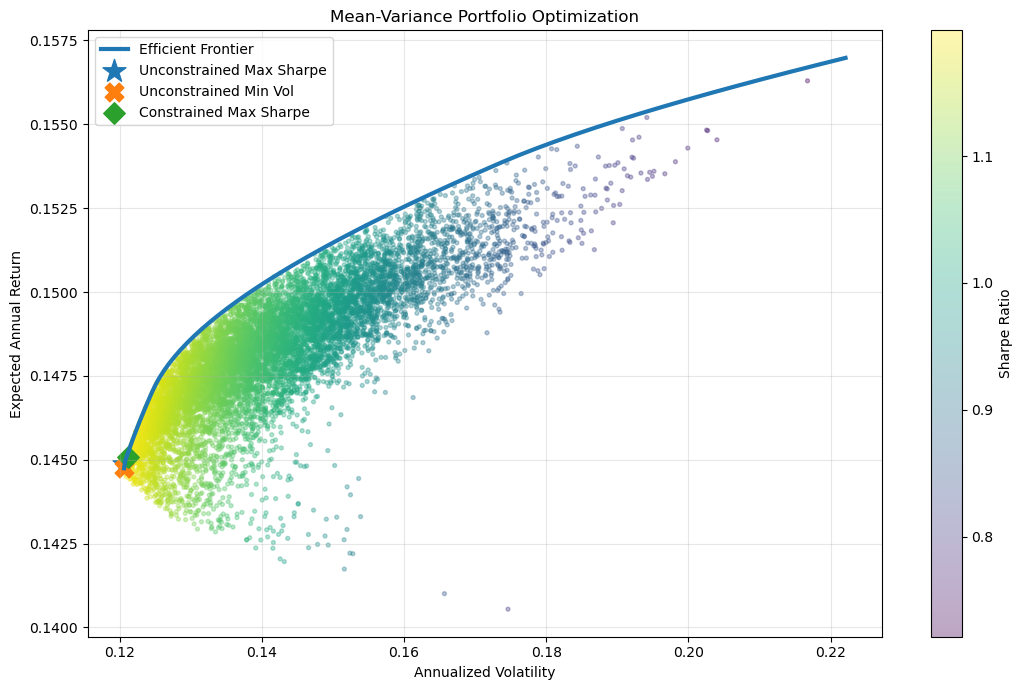


Asset Allocation Comparison:


,Unconstrained Max Sharpe,Unconstrained Min Vol,Constrained Max Sharpe,Constrained Min Vol
BRK-B,35.60%,34.15%,35.00%,35.00%
GLDM,38.36%,39.77%,35.00%,35.00%
VOO,0.00%,0.00%,0.00%,0.00%
QQQM,26.04%,26.08%,30.00%,30.00%



Portfolio Performance Comparison:


,Expected Return,Volatility,Sharpe Ratio
Unconstrained Max Sharpe,14.49%,12.07%,1.20
Unconstrained Min Vol,14.47%,12.06%,1.20
Constrained Max Sharpe,14.51%,12.11%,1.20
Constrained Min Vol,14.51%,12.11%,1.20



Optimization Status:
Unconstrained Max Sharpe: True - Optimization terminated successfully
Unconstrained Min Vol: True - Optimization terminated successfully
Constrained Max Sharpe: True - Optimization terminated successfully
Constrained Min Vol: True - Optimization terminated successfully


In [26]:
from scipy.optimize import minimize
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

num_assets = len(tickers)

cov_matrix = returns.cov() * 252

risk_free_rate = 0.00

initial_weights = np.ones(num_assets) / num_assets

constraints = (
    {
        "type": "eq",
        "fun": lambda weights: np.sum(weights) - 1
    },
)


def portfolio_return(weights):
    """
    Calculate annualized expected portfolio return.
    """
    return np.dot(
        weights,
        annualized_returns
    )


def portfolio_volatility(weights):
    """
    Calculate annualized portfolio volatility.
    """
    return np.sqrt(
        np.dot(
            weights.T,
            np.dot(
                cov_matrix,
                weights
            )
        )
    )


def portfolio_sharpe(weights):
    """
    Calculate portfolio Sharpe Ratio.
    """
    port_return = portfolio_return(weights)
    port_vol = portfolio_volatility(weights)

    return (
        port_return - risk_free_rate
    ) / port_vol


def negative_sharpe(weights):
    """
    scipy minimizes functions,
    so maximize Sharpe by minimizing negative Sharpe.
    """
    return -portfolio_sharpe(weights)

unconstrained_bounds = tuple(
    (0, 1)
    for _ in range(num_assets)
)

unconstrained_max_sharpe = minimize(
    negative_sharpe,
    initial_weights,
    method="SLSQP",
    bounds=unconstrained_bounds,
    constraints=constraints
)

weights_unconstrained_sharpe = (
    unconstrained_max_sharpe.x
)

return_unconstrained_sharpe = portfolio_return(
    weights_unconstrained_sharpe
)

vol_unconstrained_sharpe = portfolio_volatility(
    weights_unconstrained_sharpe
)

sharpe_unconstrained = portfolio_sharpe(
    weights_unconstrained_sharpe
)

unconstrained_min_vol = minimize(
    portfolio_volatility,
    initial_weights,
    method="SLSQP",
    bounds=unconstrained_bounds,
    constraints=constraints
)

weights_unconstrained_minvol = (
    unconstrained_min_vol.x
)

return_unconstrained_minvol = portfolio_return(
    weights_unconstrained_minvol
)

vol_unconstrained_minvol = portfolio_volatility(
    weights_unconstrained_minvol
)

sharpe_unconstrained_minvol = portfolio_sharpe(
    weights_unconstrained_minvol
)

max_weight = 0.35

constrained_bounds = tuple(
    (0, max_weight)
    for _ in range(num_assets)
)

constrained_max_sharpe = minimize(
    negative_sharpe,
    initial_weights,
    method="SLSQP",
    bounds=constrained_bounds,
    constraints=constraints
)

weights_constrained_sharpe = (
    constrained_max_sharpe.x
)

return_constrained_sharpe = portfolio_return(
    weights_constrained_sharpe
)

vol_constrained_sharpe = portfolio_volatility(
    weights_constrained_sharpe
)

sharpe_constrained = portfolio_sharpe(
    weights_constrained_sharpe
)

constrained_min_vol = minimize(
    portfolio_volatility,
    initial_weights,
    method="SLSQP",
    bounds=constrained_bounds,
    constraints=constraints
)

weights_constrained_minvol = (
    constrained_min_vol.x
)

return_constrained_minvol = portfolio_return(
    weights_constrained_minvol
)

vol_constrained_minvol = portfolio_volatility(
    weights_constrained_minvol
)

sharpe_constrained_minvol = portfolio_sharpe(
    weights_constrained_minvol
)

target_returns = np.linspace(
    return_unconstrained_minvol,
    annualized_returns.max(),
    60
)

frontier_returns = []
frontier_volatility = []
frontier_weights = []


for target_return in target_returns:

    frontier_constraints = (
        {
            "type": "eq",
            "fun": lambda weights: np.sum(weights) - 1
        },
        {
            "type": "eq",
            "fun": lambda weights,
            target=target_return:
            portfolio_return(weights) - target
        }
    )

    result = minimize(
        portfolio_volatility,
        initial_weights,
        method="SLSQP",
        bounds=unconstrained_bounds,
        constraints=frontier_constraints
    )

    if result.success:

        frontier_returns.append(
            portfolio_return(result.x)
        )

        frontier_volatility.append(
            portfolio_volatility(result.x)
        )

        frontier_weights.append(
            result.x
        )


frontier_returns = np.array(
    frontier_returns
)

frontier_volatility = np.array(
    frontier_volatility
)

np.random.seed(42)

num_portfolios = 10000

mc_returns = []
mc_volatility = []
mc_sharpe = []


for i in range(num_portfolios):

    weights = np.random.random(
        num_assets
    )

    weights /= np.sum(weights)

    port_return = portfolio_return(
        weights
    )

    port_vol = portfolio_volatility(
        weights
    )

    port_sharpe = portfolio_sharpe(
        weights
    )

    mc_returns.append(
        port_return
    )

    mc_volatility.append(
        port_vol
    )

    mc_sharpe.append(
        port_sharpe
    )


mc_returns = np.array(
    mc_returns
)

mc_volatility = np.array(
    mc_volatility
)

mc_sharpe = np.array(
    mc_sharpe
)

plt.figure(figsize=(11, 7))

scatter = plt.scatter(
    mc_volatility,
    mc_returns,
    c=mc_sharpe,
    cmap="viridis",
    alpha=0.35,
    s=8
)

plt.colorbar(
    scatter,
    label="Sharpe Ratio"
)

plt.plot(
    frontier_volatility,
    frontier_returns,
    linewidth=3,
    label="Efficient Frontier"
)

plt.scatter(
    vol_unconstrained_sharpe,
    return_unconstrained_sharpe,
    marker="*",
    s=300,
    label="Unconstrained Max Sharpe"
)

plt.scatter(
    vol_unconstrained_minvol,
    return_unconstrained_minvol,
    marker="X",
    s=180,
    label="Unconstrained Min Vol"
)

plt.scatter(
    vol_constrained_sharpe,
    return_constrained_sharpe,
    marker="D",
    s=120,
    label="Constrained Max Sharpe"
)


plt.xlabel(
    "Annualized Volatility"
)

plt.ylabel(
    "Expected Annual Return"
)

plt.title(
    "Mean-Variance Portfolio Optimization"
)

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

results = pd.DataFrame({

    "Unconstrained Max Sharpe":
        weights_unconstrained_sharpe,

    "Unconstrained Min Vol":
        weights_unconstrained_minvol,

    "Constrained Max Sharpe":
        weights_constrained_sharpe,

    "Constrained Min Vol":
        weights_constrained_minvol

}, index=tickers)


print("\nAsset Allocation Comparison:")

display(
    results.style.format("{:.2%}")
)

performance_comparison = pd.DataFrame({

    "Expected Return": [
        return_unconstrained_sharpe,
        return_unconstrained_minvol,
        return_constrained_sharpe,
        return_constrained_minvol
    ],

    "Volatility": [
        vol_unconstrained_sharpe,
        vol_unconstrained_minvol,
        vol_constrained_sharpe,
        vol_constrained_minvol
    ],

    "Sharpe Ratio": [
        sharpe_unconstrained,
        sharpe_unconstrained_minvol,
        sharpe_constrained,
        sharpe_constrained_minvol
    ]

}, index=[

    "Unconstrained Max Sharpe",
    "Unconstrained Min Vol",
    "Constrained Max Sharpe",
    "Constrained Min Vol"

])


print("\nPortfolio Performance Comparison:")

display(
    performance_comparison.style.format({
        "Expected Return": "{:.2%}",
        "Volatility": "{:.2%}",
        "Sharpe Ratio": "{:.2f}"
    })
)

print("\nOptimization Status:")

print(
    "Unconstrained Max Sharpe:",
    unconstrained_max_sharpe.success,
    "-",
    unconstrained_max_sharpe.message
)

print(
    "Unconstrained Min Vol:",
    unconstrained_min_vol.success,
    "-",
    unconstrained_min_vol.message
)

print(
    "Constrained Max Sharpe:",
    constrained_max_sharpe.success,
    "-",
    constrained_max_sharpe.message
)

print(
    "Constrained Min Vol:",
    constrained_min_vol.success,
    "-",
    constrained_min_vol.message
)

## 6. Walk-Forward Out-of-Sample Backtesting

Static optimization using the full historical dataset may introduce **look-ahead bias**, because future information can indirectly influence portfolio construction.

To reduce this problem, a walk-forward framework is used.

At each rebalance date:

1. Only historical information available at that time is used.
2. Portfolio weights are estimated from the historical training window.
3. The estimated weights are applied to the following out-of-sample period.
4. The process is repeated through time.

Conceptually:

**Historical Data → Estimate Weights → Future Returns → Rebalance → Repeat**

If portfolio weights are estimated at time $t$, the next-period portfolio return is:

$$
R_{p,t+1}
=
w_t^\top R_{t+1}
$$

This provides a more realistic assessment of out-of-sample portfolio performance.

Rebalance dates:
2022-12-31
2023-12-31
2024-12-31
2025-12-31
2026-12-31


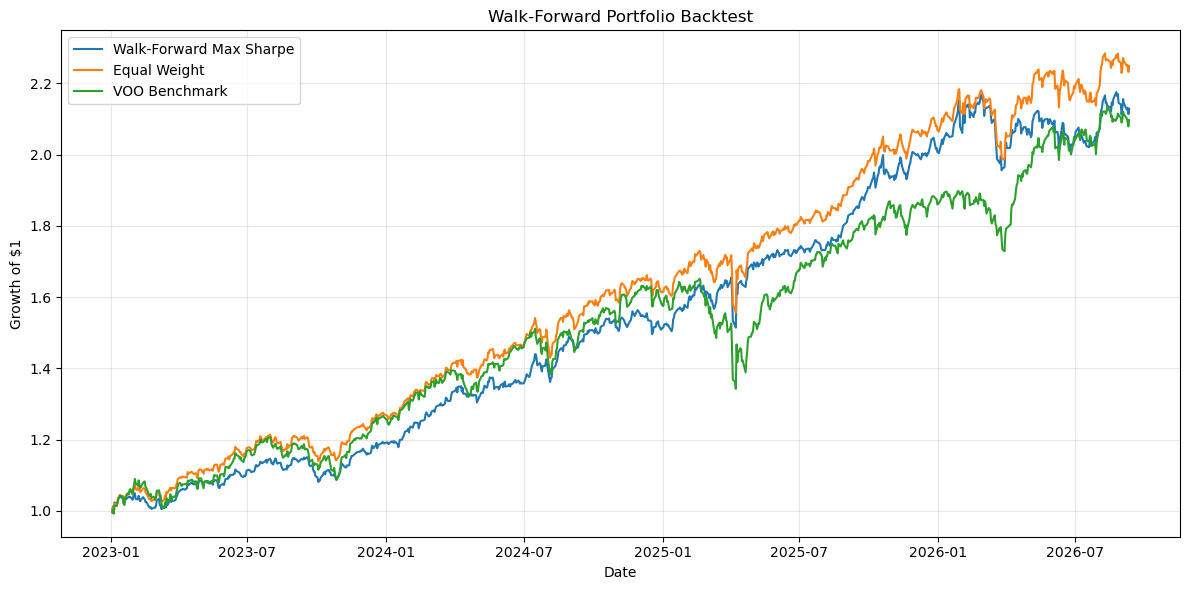


Backtest Performance:


,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown
Walk-Forward Max Sharpe,21.24%,11.60%,1.83,-9.79%
Equal Weight,22.80%,12.19%,1.87,-10.02%
VOO Benchmark,21.22%,14.63%,1.45,-18.69%



Portfolio Weight History:


Ticker,BRK-B,GLDM,QQQM,VOO
2022-12-31 00:00:00,35.00%,30.00%,0.00%,35.00%
2023-12-31 00:00:00,35.00%,35.00%,0.00%,30.00%
2024-12-31 00:00:00,30.00%,35.00%,35.00%,0.00%
2025-12-31 00:00:00,30.00%,35.00%,0.00%,35.00%
2026-12-31 00:00:00,11.05%,35.00%,18.95%,35.00%


In [27]:
from scipy.optimize import minimize
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


lookback_days = 504       # About 2 trading years
rebalance_frequency = "YE"   # Rebalance once per year
max_weight = 0.35
risk_free_rate = 0.00

simple_returns = data.pct_change().dropna()

def optimize_max_sharpe(training_returns):

    num_assets = training_returns.shape[1]

    annual_returns = (
        training_returns.mean() * 252
    )

    annual_cov = (
        training_returns.cov() * 252
    )

    initial_weights = (
        np.ones(num_assets) / num_assets
    )

    bounds = tuple(
        (0, max_weight)
        for _ in range(num_assets)
    )

    constraints = (
        {
            "type": "eq",
            "fun": lambda weights:
            np.sum(weights) - 1
        },
    )


    def negative_sharpe(weights):

        port_return = np.dot(
            weights,
            annual_returns
        )

        port_vol = np.sqrt(
            np.dot(
                weights.T,
                np.dot(
                    annual_cov,
                    weights
                )
            )
        )

        if port_vol == 0:
            return 999

        sharpe = (
            port_return - risk_free_rate
        ) / port_vol

        return -sharpe


    result = minimize(
        negative_sharpe,
        initial_weights,
        method="SLSQP",
        bounds=bounds,
        constraints=constraints
    )


    if result.success:
        return result.x

    else:
        # Fallback to equal weight
        return initial_weights

rebalance_dates = (
    simple_returns
    .resample(rebalance_frequency)
    .last()
    .index
)

valid_rebalance_dates = []

for date in rebalance_dates:

    available_data = simple_returns.loc[
        simple_returns.index < date
    ]

    if len(available_data) >= lookback_days:
        valid_rebalance_dates.append(date)


print("Rebalance dates:")

for date in valid_rebalance_dates:
    print(date.date())

strategy_returns = pd.Series(
    index=simple_returns.index,
    dtype=float
)

equal_weight_returns = pd.Series(
    index=simple_returns.index,
    dtype=float
)

weight_history = []


for i, rebalance_date in enumerate(
    valid_rebalance_dates
):

    training_data = simple_returns.loc[
        simple_returns.index < rebalance_date
    ].tail(
        lookback_days
    )

    optimal_weights = optimize_max_sharpe(
        training_data
    )

    weight_history.append(
        pd.Series(
            optimal_weights,
            index=simple_returns.columns,
            name=rebalance_date
        )
    )

    start_date = rebalance_date


    if i < len(valid_rebalance_dates) - 1:

        end_date = valid_rebalance_dates[
            i + 1
        ]

    else:

        end_date = simple_returns.index.max()


    test_data = simple_returns.loc[
        (simple_returns.index > start_date)
        &
        (simple_returns.index <= end_date)
    ]

    strategy_returns.loc[
        test_data.index
    ] = np.dot(
        test_data,
        optimal_weights
    )

    equal_weights = np.ones(
        len(simple_returns.columns)
    ) / len(simple_returns.columns)


    equal_weight_returns.loc[
        test_data.index
    ] = np.dot(
        test_data,
        equal_weights
    )

strategy_returns = (
    strategy_returns
    .dropna()
)

equal_weight_returns = (
    equal_weight_returns
    .reindex(strategy_returns.index)
)

voo_returns = (
    simple_returns["VOO"]
    .reindex(strategy_returns.index)
)

strategy_growth = (
    1 + strategy_returns
).cumprod()

equal_growth = (
    1 + equal_weight_returns
).cumprod()

voo_growth = (
    1 + voo_returns
).cumprod()

plt.figure(figsize=(12, 6))

plt.plot(
    strategy_growth,
    label="Walk-Forward Max Sharpe"
)

plt.plot(
    equal_growth,
    label="Equal Weight"
)

plt.plot(
    voo_growth,
    label="VOO Benchmark"
)

plt.title(
    "Walk-Forward Portfolio Backtest"
)

plt.xlabel("Date")
plt.ylabel("Growth of $1")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

def calculate_metrics(return_series):

    annual_return = (
        return_series.mean() * 252
    )

    annual_volatility = (
        return_series.std()
        * np.sqrt(252)
    )

    sharpe_ratio = (
        annual_return - risk_free_rate
    ) / annual_volatility


    cumulative = (
        1 + return_series
    ).cumprod()


    rolling_max = cumulative.cummax()

    drawdown = (
        cumulative / rolling_max
    ) - 1

    max_drawdown = drawdown.min()


    return [
        annual_return,
        annual_volatility,
        sharpe_ratio,
        max_drawdown
    ]


performance = pd.DataFrame(

    {
        "Walk-Forward Max Sharpe":
            calculate_metrics(
                strategy_returns
            ),

        "Equal Weight":
            calculate_metrics(
                equal_weight_returns
            ),

        "VOO Benchmark":
            calculate_metrics(
                voo_returns
            )
    },

    index=[
        "Annualized Return",
        "Annualized Volatility",
        "Sharpe Ratio",
        "Max Drawdown"
    ]

).T


print("\nBacktest Performance:")

display(
    performance.style.format({
        "Annualized Return": "{:.2%}",
        "Annualized Volatility": "{:.2%}",
        "Sharpe Ratio": "{:.2f}",
        "Max Drawdown": "{:.2%}"
    })
)

weight_history_df = pd.DataFrame(
    weight_history
)

print("\nPortfolio Weight History:")

display(
    weight_history_df.style.format(
        "{:.2%}"
    )
)

## 7. Robustness Testing

Portfolio optimization can be sensitive to the historical period used to estimate expected returns and covariance.

To test whether the results depend heavily on one particular estimation window, three lookback periods are compared:

- **1-Year MVO** — 252 trading days
- **2-Year MVO** — 504 trading days
- **3-Year MVO** — 756 trading days

The strategies are compared with:

- Equal Weight Portfolio
- VOO Benchmark

Portfolio turnover is calculated as:

$$
Turnover_t
=
\frac{1}{2}
\sum_{i=1}^{N}
\left|
w_{i,t}-w_{i,t-1}
\right|
$$

Transaction costs are then incorporated into the walk-forward backtest.

Performance is evaluated using:

- Annualized Return
- Annualized Volatility
- Sharpe Ratio
- Maximum Drawdown
- Portfolio Turnover

Consistent results across different lookback windows provide stronger evidence that the findings are not driven by one arbitrary parameter choice.

Available data:
2020-10-14 00:00:00 to 2026-09-11 00:00:00
Observations: 1484
Running 1-Year MVO...
Running 2-Year MVO...
Running 3-Year MVO...

Common comparison period:
2024-01-02 00:00:00 to 2026-09-11 00:00:00


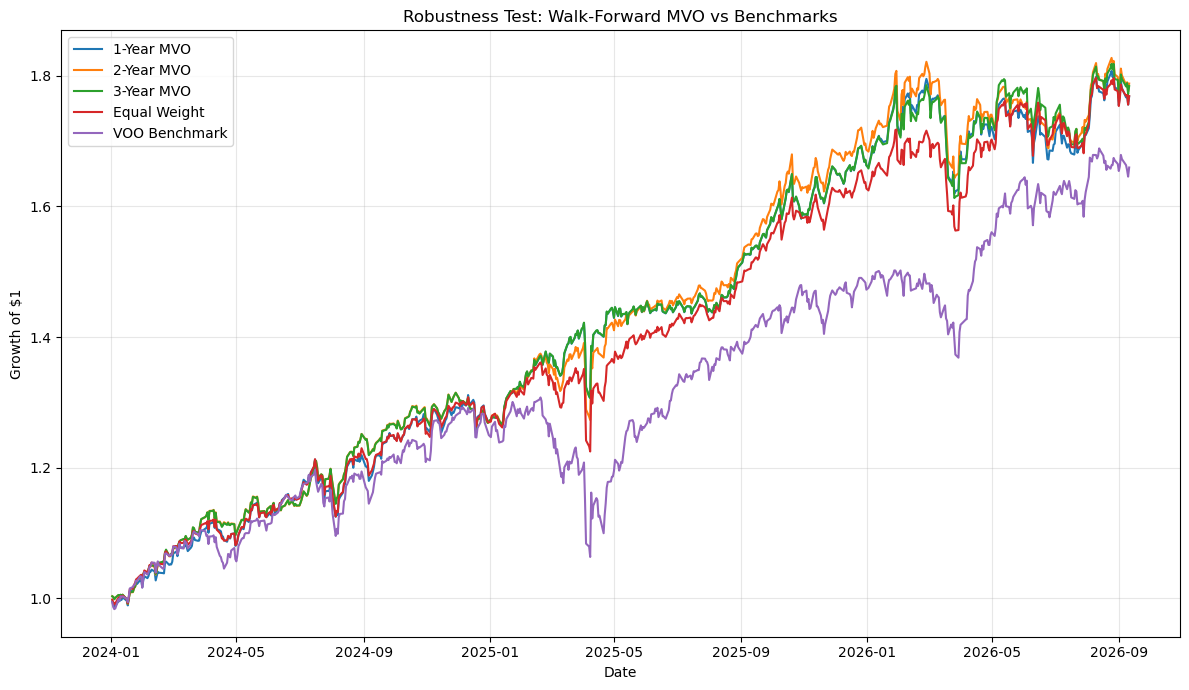


Performance Comparison:


,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown
1-Year MVO,23.68%,12.49%,1.90,-9.78%
2-Year MVO,24.19%,12.35%,1.96,-9.79%
3-Year MVO,24.09%,12.39%,1.94,-9.68%
Equal Weight,23.69%,12.79%,1.85,-10.02%
VOO Benchmark,20.79%,15.19%,1.37,-18.69%



Turnover Comparison:


,Average Turnover,Maximum Turnover,Total Turnover
1-Year MVO,22.43%,35.00%,112.13%
2-Year MVO,18.75%,35.00%,75.00%
3-Year MVO,11.61%,33.61%,34.83%



1-Year MVO — Weight History:


Ticker,BRK-B,GLDM,QQQM,VOO
2021-12-31 00:00:00,35.00%,0.00%,30.00%,35.00%
2022-12-30 00:00:00,35.00%,35.00%,0.00%,30.00%
2023-12-29 00:00:00,17.88%,35.00%,35.00%,12.12%
2024-12-31 00:00:00,35.00%,35.00%,0.00%,30.00%
2025-12-31 00:00:00,27.87%,35.00%,2.13%,35.00%



2-Year MVO — Weight History:


Ticker,BRK-B,GLDM,QQQM,VOO
2022-12-30 00:00:00,35.00%,30.00%,0.00%,35.00%
2023-12-29 00:00:00,35.00%,35.00%,0.00%,30.00%
2024-12-31 00:00:00,30.00%,35.00%,35.00%,0.00%
2025-12-31 00:00:00,30.00%,35.00%,0.00%,35.00%



3-Year MVO — Weight History:


Ticker,BRK-B,GLDM,QQQM,VOO
2023-12-29 00:00:00,35.00%,33.79%,0.00%,31.21%
2024-12-31 00:00:00,35.00%,35.00%,0.00%,30.00%
2025-12-31 00:00:00,31.39%,35.00%,33.61%,0.00%


In [28]:
from scipy.optimize import minimize
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

TRADING_DAYS = 252

lookback_periods = {
    "1-Year MVO": 252,
    "2-Year MVO": 504,
    "3-Year MVO": 756
}

max_weight = 0.35

transaction_cost_rate = 0.001

risk_free_rate = 0.00

simple_returns = (
    data
    .pct_change(fill_method=None)
    .dropna()
)

print("Available data:")
print(
    simple_returns.index.min(),
    "to",
    simple_returns.index.max()
)

print(
    "Observations:",
    len(simple_returns)
)

def optimize_portfolio(training_returns):

    n_assets = training_returns.shape[1]

    expected_returns = (
        training_returns.mean()
        * TRADING_DAYS
    )

    covariance_matrix = (
        training_returns.cov()
        * TRADING_DAYS
    )

    initial_weights = (
        np.ones(n_assets)
        / n_assets
    )

    bounds = tuple(
        (0, max_weight)
        for _ in range(n_assets)
    )

    constraints = (
        {
            "type": "eq",
            "fun": lambda w:
            np.sum(w) - 1
        },
    )


    def negative_sharpe(w):

        expected_return = np.dot(
            w,
            expected_returns
        )

        volatility = np.sqrt(
            w.T
            @ covariance_matrix
            @ w
        )

        if volatility <= 0:
            return 1e10

        return -(
            (expected_return - risk_free_rate)
            / volatility
        )


    result = minimize(
        negative_sharpe,
        initial_weights,
        method="SLSQP",
        bounds=bounds,
        constraints=constraints
    )


    if result.success:
        return result.x

    return initial_weights

def run_walk_forward(
    returns_data,
    lookback_days
):

    year_end_dates = (
        returns_data
        .groupby(returns_data.index.year)
        .apply(lambda x: x.index.max())
        .tolist()
    )

    valid_rebalance_dates = []

    for date in year_end_dates:

        historical_data = returns_data.loc[
            returns_data.index <= date
        ]

        # Must have enough history
        # AND there must be future data
        if (
            len(historical_data) >= lookback_days
            and date < returns_data.index.max()
        ):
            valid_rebalance_dates.append(date)


    strategy_returns = pd.Series(
        index=returns_data.index,
        dtype=float
    )

    weight_records = []

    turnover_records = []

    previous_weights = None

    for i, rebalance_date in enumerate(
        valid_rebalance_dates
    ):
        training_data = (
            returns_data
            .loc[
                returns_data.index
                <= rebalance_date
            ]
            .tail(lookback_days)
        )


        optimal_weights = optimize_portfolio(
            training_data
        )

        if previous_weights is None:
            turnover = 0.0

        else:

            turnover = (
                0.5
                * np.sum(
                    np.abs(
                        optimal_weights
                        - previous_weights
                    )
                )
            )


        turnover_records.append(
            {
                "Date": rebalance_date,
                "Turnover": turnover
            }
        )


        weight_records.append(
            pd.Series(
                optimal_weights,
                index=returns_data.columns,
                name=rebalance_date
            )
        )

        start_date = rebalance_date

        if i < len(valid_rebalance_dates) - 1:

            end_date = (
                valid_rebalance_dates[i + 1]
            )

        else:

            end_date = (
                returns_data.index.max()
            )


        test_data = returns_data.loc[
            (returns_data.index > start_date)
            &
            (returns_data.index <= end_date)
        ]


        if test_data.empty:
            previous_weights = optimal_weights
            continue


        daily_portfolio_returns = (
            test_data
            @ optimal_weights
        )

        trading_cost = (
            turnover
            * transaction_cost_rate
        )


        daily_portfolio_returns = (
            daily_portfolio_returns.copy()
        )


        daily_portfolio_returns.iloc[0] -= (
            trading_cost
        )


        strategy_returns.loc[
            test_data.index
        ] = daily_portfolio_returns


        previous_weights = (
            optimal_weights.copy()
        )


    strategy_returns = (
        strategy_returns.dropna()
    )


    weights_df = pd.DataFrame(
        weight_records
    )


    turnover_df = pd.DataFrame(
        turnover_records
    )


    return (
        strategy_returns,
        weights_df,
        turnover_df
    )

strategy_results = {}
weight_results = {}
turnover_results = {}


for strategy_name, lookback_days in (
    lookback_periods.items()
):

    print(
        f"Running {strategy_name}..."
    )

    (
        strategy_return,
        strategy_weights,
        strategy_turnover

    ) = run_walk_forward(
        simple_returns,
        lookback_days
    )


    strategy_results[
        strategy_name
    ] = strategy_return


    weight_results[
        strategy_name
    ] = strategy_weights


    turnover_results[
        strategy_name
    ] = strategy_turnover

common_start = max(
    result.index.min()
    for result in strategy_results.values()
)

common_end = min(
    result.index.max()
    for result in strategy_results.values()
)


print("\nCommon comparison period:")

print(
    common_start,
    "to",
    common_end
)


comparison_returns = pd.DataFrame()


for name, result in strategy_results.items():

    comparison_returns[name] = (
        result.loc[
            common_start:common_end
        ]
    )

equal_weights = (
    np.ones(
        len(simple_returns.columns)
    )
    / len(simple_returns.columns)
)


comparison_returns[
    "Equal Weight"
] = (
    simple_returns
    .loc[
        common_start:common_end
    ]
    @ equal_weights
)


# VOO benchmark

comparison_returns[
    "VOO Benchmark"
] = (
    simple_returns["VOO"]
    .loc[
        common_start:common_end
    ]
)


comparison_returns = (
    comparison_returns.dropna()
)

growth = (
    1 + comparison_returns
).cumprod()


plt.figure(figsize=(12, 7))


for column in growth.columns:

    plt.plot(
        growth.index,
        growth[column],
        label=column
    )


plt.title(
    "Robustness Test: "
    "Walk-Forward MVO vs Benchmarks"
)

plt.xlabel("Date")

plt.ylabel("Growth of $1")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

def calculate_performance(
    return_series
):

    n = len(return_series)

    # CAGR instead of arithmetic mean return
    cumulative_growth = (
        1 + return_series
    ).prod()


    annualized_return = (
        cumulative_growth
        ** (TRADING_DAYS / n)
        - 1
    )


    annualized_volatility = (
        return_series.std()
        * np.sqrt(TRADING_DAYS)
    )


    sharpe = (
        annualized_return
        - risk_free_rate
    ) / annualized_volatility


    wealth = (
        1 + return_series
    ).cumprod()


    running_max = wealth.cummax()


    drawdown = (
        wealth / running_max
        - 1
    )


    max_drawdown = (
        drawdown.min()
    )


    return {
        "Annualized Return": annualized_return,
        "Annualized Volatility":
            annualized_volatility,
        "Sharpe Ratio": sharpe,
        "Max Drawdown": max_drawdown
    }

performance_results = {}


for column in comparison_returns.columns:

    performance_results[
        column
    ] = calculate_performance(
        comparison_returns[column]
    )


performance_table = (
    pd.DataFrame(
        performance_results
    ).T
)


print(
    "\nPerformance Comparison:"
)


display(
    performance_table.style.format({
        "Annualized Return": "{:.2%}",
        "Annualized Volatility": "{:.2%}",
        "Sharpe Ratio": "{:.2f}",
        "Max Drawdown": "{:.2%}"
    })
)

turnover_summary = {}


for name, turnover_df in (
    turnover_results.items()
):

    if turnover_df.empty:

        turnover_summary[name] = {
            "Average Turnover": np.nan,
            "Maximum Turnover": np.nan,
            "Total Turnover": np.nan
        }

    else:

        turnover_summary[name] = {

            "Average Turnover":
                turnover_df[
                    "Turnover"
                ].mean(),

            "Maximum Turnover":
                turnover_df[
                    "Turnover"
                ].max(),

            "Total Turnover":
                turnover_df[
                    "Turnover"
                ].sum()
        }


turnover_table = (
    pd.DataFrame(
        turnover_summary
    ).T
)


print(
    "\nTurnover Comparison:"
)


display(
    turnover_table.style.format({
        "Average Turnover": "{:.2%}",
        "Maximum Turnover": "{:.2%}",
        "Total Turnover": "{:.2%}"
    })
)

for name, weights_df in (
    weight_results.items()
):

    print(
        f"\n{name} — Weight History:"
    )

    display(
        weights_df.style.format(
            "{:.2%}"
        )
    )

## 8. VIX-Based Market Regime Analysis

Portfolio performance may vary significantly across different market environments.

The CBOE Volatility Index (VIX) is used as a descriptive proxy for market uncertainty.

Market conditions are classified into three regimes:

$$
VIX < 15
\Rightarrow
\text{Low Volatility}
$$

$$
15 \leq VIX < 25
\Rightarrow
\text{Normal}
$$

$$
VIX \geq 25
\Rightarrow
\text{High Volatility}
$$

The 2-Year MVO strategy, Equal Weight portfolio, and VOO benchmark are evaluated separately across these regimes.

The purpose is not to use VIX to predict future returns, but to examine how portfolio risk and performance change when market conditions become more stressful.

In [34]:
import yfinance as yf
import pandas as pd

print("Downloading VIX data...")

vix_data = yf.Ticker("^VIX").history(
    start="2018-01-01",
    auto_adjust=False
)

if vix_data.empty:
    raise RuntimeError(
        "VIX download failed. No file was saved. "
        "Please try again later."
    )

vix_data = vix_data[["Close"]].copy()

if vix_data.index.tz is not None:
    vix_data.index = vix_data.index.tz_localize(None)

vix_data.index.name = "Date"

vix_data.to_csv(
    "vix_data.csv"
)

print("VIX data saved successfully.")
print(
    "Period:",
    vix_data.index.min(),
    "to",
    vix_data.index.max()
)
print(
    "Observations:",
    len(vix_data)
)

display(
    vix_data.tail()
)

VIX data saved successfully.
Period: 2018-01-02 00:00:00 to 2026-09-11 00:00:00
Observations: 2187


,Close
Date,
2026-09-07,15.300000
2026-09-08,15.720000
2026-09-09,16.459999
2026-09-10,17.840000
2026-09-11,15.840000


VIX data loaded successfully.

Raw VIX period: 2018-01-02 00:00:00 to 2026-09-11 00:00:00
Raw VIX observations: 2187

VIX aligned period: 2024-01-02 00:00:00 to 2026-09-11 00:00:00

Missing VIX values: 0

VIX Summary:


count    676.000000
mean      17.581287
std        4.488817
min       11.860000
25%       14.910000
50%       16.550000
75%       18.964999
max       52.330002
Name: Close, dtype: float64


Market Regime Distribution:


Market Regime
Normal             460
Low Volatility     178
High Volatility     38
Name: count, dtype: int64

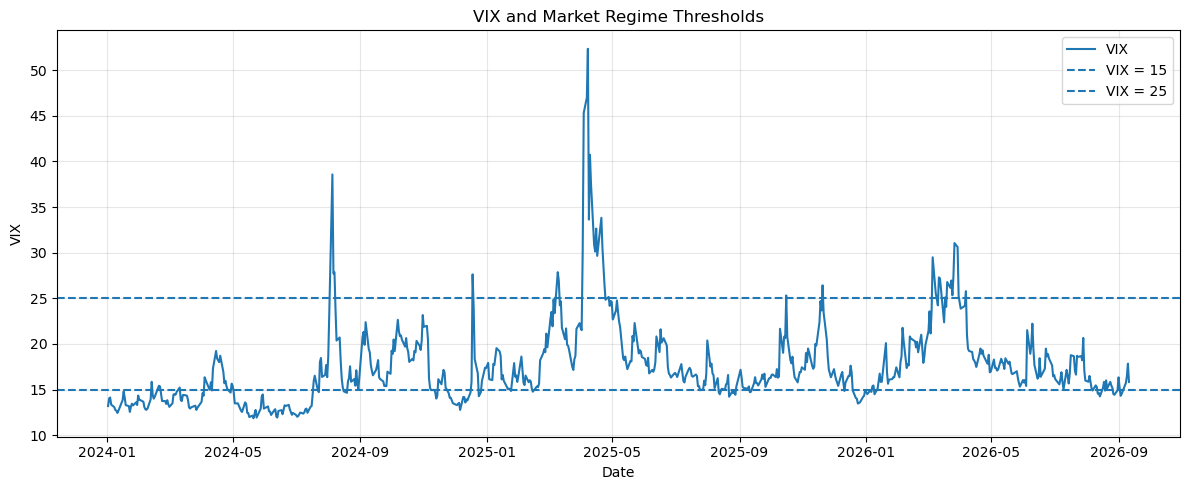


Performance by Market Regime:


,Market Regime,Strategy,Average Daily Return,Annualized Return,Annualized Volatility,Sharpe Ratio,Worst Day,Observations
0,Low Volatility,2-Year MVO,0.177%,44.70%,8.65%,5.17,-1.61%,178
1,Low Volatility,Equal Weight,0.203%,51.18%,8.33%,6.14,-1.28%,178
2,Low Volatility,VOO Benchmark,0.215%,54.31%,8.96%,6.06,-1.63%,178
3,Normal,2-Year MVO,0.077%,19.46%,11.09%,1.75,-3.40%,460
4,Normal,Equal Weight,0.073%,18.44%,11.36%,1.62,-2.70%,460
5,Normal,VOO Benchmark,0.074%,18.59%,13.18%,1.41,-2.69%,460
6,High Volatility,2-Year MVO,-0.182%,-45.82%,29.52%,-1.55,-5.00%,38
7,High Volatility,Equal Weight,-0.278%,-69.99%,31.65%,-2.21,-5.27%,38
8,High Volatility,VOO Benchmark,-0.488%,-122.93%,39.58%,-3.11,-5.80%,38



Annualized Return by Regime:


Strategy,2-Year MVO,Equal Weight,VOO Benchmark
Market Regime,,,
Low Volatility,44.70%,51.18%,54.31%
Normal,19.46%,18.44%,18.59%
High Volatility,-45.82%,-69.99%,-122.93%



Annualized Volatility by Regime:


...


Sharpe Ratio by Regime:


Strategy,2-Year MVO,Equal Weight,VOO Benchmark
Market Regime,,,
Low Volatility,5.17,6.14,6.06
Normal,1.75,1.62,1.41
High Volatility,-1.55,-2.21,-3.11



Worst Daily Return by Regime:


Strategy,2-Year MVO,Equal Weight,VOO Benchmark
Market Regime,,,
Low Volatility,-1.61%,-1.28%,-1.63%
Normal,-3.40%,-2.70%,-2.69%
High Volatility,-5.00%,-5.27%,-5.80%



Number of High-Volatility Days: 38


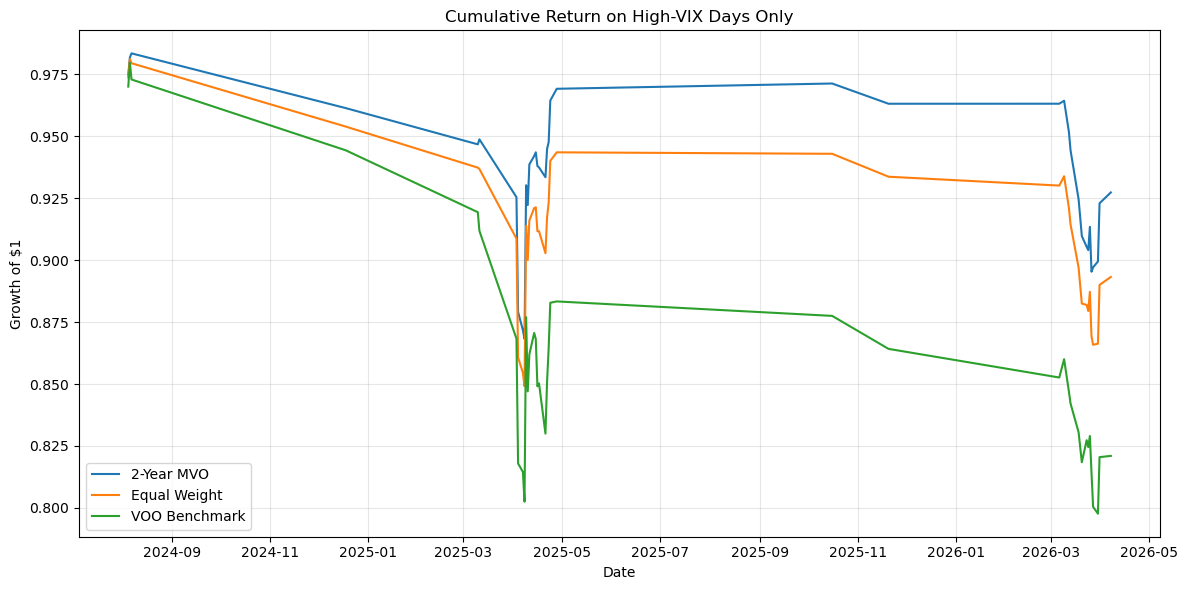

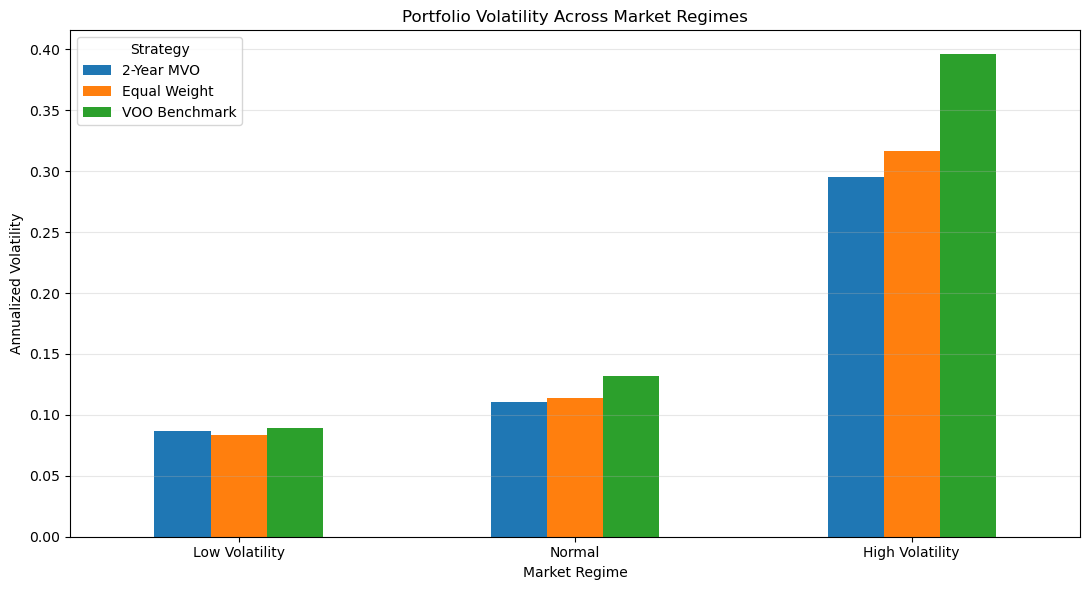

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

vix_data = pd.read_csv(
    "vix_data.csv"
)

vix_data["Date"] = pd.to_datetime(
    vix_data["Date"],
    errors="coerce"
)

vix_data["Close"] = pd.to_numeric(
    vix_data["Close"],
    errors="coerce"
)

vix_data = (
    vix_data
    .dropna(
        subset=["Date", "Close"]
    )
    .set_index("Date")
    .sort_index()
)

vix = vix_data["Close"].copy()

print("VIX data loaded successfully.")

print(
    "\nRaw VIX period:",
    vix.index.min(),
    "to",
    vix.index.max()
)

print(
    "Raw VIX observations:",
    len(vix)
)

vix = (
    vix
    .reindex(
        comparison_returns.index
    )
    .ffill()
)

print(
    "\nVIX aligned period:",
    vix.index.min(),
    "to",
    vix.index.max()
)

print(
    "\nMissing VIX values:",
    vix.isna().sum()
)

print("\nVIX Summary:")

display(
    vix.describe()
)


def classify_regime(vix_value):

    if pd.isna(vix_value):
        return np.nan

    if vix_value < 15:
        return "Low Volatility"

    if vix_value < 25:
        return "Normal"

    return "High Volatility"


market_regime = (
    vix.apply(
        classify_regime
    )
)

regime_data = (
    comparison_returns.copy()
)

regime_data["VIX"] = vix

regime_data[
    "Market Regime"
] = market_regime

regime_data = (
    regime_data
    .dropna(
        subset=[
            "VIX",
            "Market Regime"
        ]
    )
)

print(
    "\nMarket Regime Distribution:"
)

regime_distribution = (
    regime_data[
        "Market Regime"
    ]
    .value_counts()
)

display(
    regime_distribution
)


plt.figure(
    figsize=(12, 5)
)

plt.plot(
    vix.index,
    vix,
    label="VIX"
)

plt.axhline(
    15,
    linestyle="--",
    label="VIX = 15"
)

plt.axhline(
    25,
    linestyle="--",
    label="VIX = 25"
)

plt.title(
    "VIX and Market Regime Thresholds"
)

plt.xlabel("Date")
plt.ylabel("VIX")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


strategies_to_compare = [
    "2-Year MVO",
    "Equal Weight",
    "VOO Benchmark"
]


def calculate_regime_metrics(
    return_series
):

    return_series = (
        return_series
        .dropna()
    )

    observations = len(
        return_series
    )

    if observations < 2:

        return {
            "Average Daily Return":
                np.nan,

            "Annualized Return":
                np.nan,

            "Annualized Volatility":
                np.nan,

            "Sharpe Ratio":
                np.nan,

            "Worst Day":
                np.nan,

            "Observations":
                observations
        }

    average_daily_return = (
        return_series.mean()
    )

    annualized_return = (
        average_daily_return
        * 252
    )

    annualized_volatility = (
        return_series.std()
        * np.sqrt(252)
    )

    if annualized_volatility > 0:

        sharpe_ratio = (
            annualized_return
            - risk_free_rate
        ) / annualized_volatility

    else:

        sharpe_ratio = np.nan

    worst_day = (
        return_series.min()
    )

    return {
        "Average Daily Return":
            average_daily_return,

        "Annualized Return":
            annualized_return,

        "Annualized Volatility":
            annualized_volatility,

        "Sharpe Ratio":
            sharpe_ratio,

        "Worst Day":
            worst_day,

        "Observations":
            observations
    }


regime_order = [
    "Low Volatility",
    "Normal",
    "High Volatility"
]

regime_results = []


for regime in regime_order:

    regime_subset = (
        regime_data[
            regime_data[
                "Market Regime"
            ] == regime
        ]
    )

    for strategy in strategies_to_compare:

        metrics = (
            calculate_regime_metrics(
                regime_subset[
                    strategy
                ]
            )
        )

        regime_results.append({
            "Market Regime":
                regime,

            "Strategy":
                strategy,

            **metrics
        })


regime_results_df = pd.DataFrame(
    regime_results
)


print(
    "\nPerformance by Market Regime:"
)

display(
    regime_results_df.style.format({
        "Average Daily Return":
            "{:.3%}",

        "Annualized Return":
            "{:.2%}",

        "Annualized Volatility":
            "{:.2%}",

        "Sharpe Ratio":
            "{:.2f}",

        "Worst Day":
            "{:.2%}",

        "Observations":
            "{:.0f}"
    })
)


return_pivot = (
    regime_results_df
    .pivot(
        index="Market Regime",
        columns="Strategy",
        values="Annualized Return"
    )
    .reindex(
        regime_order
    )
)

print(
    "\nAnnualized Return by Regime:"
)

display(
    return_pivot.style.format(
        "{:.2%}"
    )
)


volatility_pivot = (
    regime_results_df
    .pivot(
        index="Market Regime",
        columns="Strategy",
        values="Annualized Volatility"
    )
    .reindex(
        regime_order
    )
)

print(
    "\nAnnualized Volatility by Regime:"
)

display(
    volatility_pivot.style.format(
        "{:.2%}"
    )
)


sharpe_pivot = (
    regime_results_df
    .pivot(
        index="Market Regime",
        columns="Strategy",
        values="Sharpe Ratio"
    )
    .reindex(
        regime_order
    )
)

print(
    "\nSharpe Ratio by Regime:"
)

display(
    sharpe_pivot.style.format(
        "{:.2f}"
    )
)


worst_day_pivot = (
    regime_results_df
    .pivot(
        index="Market Regime",
        columns="Strategy",
        values="Worst Day"
    )
    .reindex(
        regime_order
    )
)

print(
    "\nWorst Daily Return by Regime:"
)

display(
    worst_day_pivot.style.format(
        "{:.2%}"
    )
)


high_vol_data = (
    regime_data[
        regime_data[
            "Market Regime"
        ] == "High Volatility"
    ]
)

print(
    "\nNumber of High-Volatility Days:",
    len(high_vol_data)
)


if len(high_vol_data) > 0:

    high_vol_growth = (
        1
        + high_vol_data[
            strategies_to_compare
        ]
    ).cumprod()

    plt.figure(
        figsize=(12, 6)
    )

    for strategy in strategies_to_compare:

        plt.plot(
            high_vol_growth.index,
            high_vol_growth[
                strategy
            ],
            label=strategy
        )

    plt.title(
        "Cumulative Return on High-VIX Days Only"
    )

    plt.xlabel("Date")

    plt.ylabel(
        "Growth of $1"
    )

    plt.legend()

    plt.grid(
        alpha=0.3
    )

    plt.tight_layout()
    plt.show()


volatility_pivot.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title(
    "Portfolio Volatility Across Market Regimes"
)

plt.xlabel(
    "Market Regime"
)

plt.ylabel(
    "Annualized Volatility"
)

plt.xticks(
    rotation=0
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

## 9. Asset-Level Market Regime Analysis

Portfolio-level performance does not fully explain why the strategy behaves differently across market regimes.

This section therefore examines the behaviour of each asset individually.

For BRK-B, GLDM, QQQM, and VOO, the following statistics are evaluated within each VIX regime:

- Average Daily Return
- Annualized Volatility
- Worst Daily Return
- Positive-Day Ratio
- Number of Observations

Asset correlations are also recalculated during high-VIX periods.

The correlation between two assets is:

$$
\rho_{ij}
=
\frac{\operatorname{Cov}(R_i,R_j)}
{\sigma_i\sigma_j}
$$

This analysis helps identify which assets behave differently from the broader equity market and may provide diversification benefits during periods of elevated volatility.


Asset Performance by Market Regime:


,Market Regime,Asset,Average Daily Return,Annualized Volatility,Worst Day,Positive Day Ratio,Observations
0,Low Volatility,BRK-B,0.171%,12.12%,-1.96%,59.0%,178
1,Low Volatility,GLDM,0.148%,16.96%,-4.36%,57.3%,178
2,Low Volatility,QQQM,0.277%,13.56%,-2.92%,64.0%,178
3,Low Volatility,VOO,0.215%,8.96%,-1.63%,65.7%,178
4,Normal,BRK-B,0.035%,15.98%,-5.12%,51.1%,460
5,Normal,GLDM,0.109%,22.58%,-10.08%,55.7%,460
6,Normal,QQQM,0.074%,19.21%,-4.78%,55.9%,460
7,Normal,VOO,0.074%,13.18%,-2.69%,54.8%,460
8,High Volatility,BRK-B,-0.193%,30.82%,-6.91%,36.8%,38
9,High Volatility,GLDM,0.110%,33.10%,-3.72%,44.7%,38



Average Daily Return by Regime:


Asset,BRK-B,GLDM,QQQM,VOO
Market Regime,,,,
Low Volatility,0.171%,0.148%,0.277%,0.215%
Normal,0.035%,0.109%,0.074%,0.074%
High Volatility,-0.193%,0.110%,-0.540%,-0.488%



Annualized Volatility by Regime:


Asset,BRK-B,GLDM,QQQM,VOO
Market Regime,,,,
Low Volatility,12.12%,16.96%,13.56%,8.96%
Normal,15.98%,22.58%,19.21%,13.18%
High Volatility,30.82%,33.10%,47.39%,39.58%



Number of High-VIX Days: 38

High-VIX Asset Summary:


,Average Daily Return,Volatility,Worst Day,Positive Day Ratio
Ticker,,,,
GLDM,0.110%,33.10%,-3.72%,44.7%
BRK-B,-0.193%,30.82%,-6.91%,36.8%
VOO,-0.488%,39.58%,-5.80%,36.8%
QQQM,-0.540%,47.39%,-6.11%,36.8%



High-VIX Protection Relative to VOO:


,Daily Return Advantage vs VOO
Ticker,
GLDM,+0.598%
BRK-B,+0.295%
VOO,+0.000%
QQQM,-0.052%


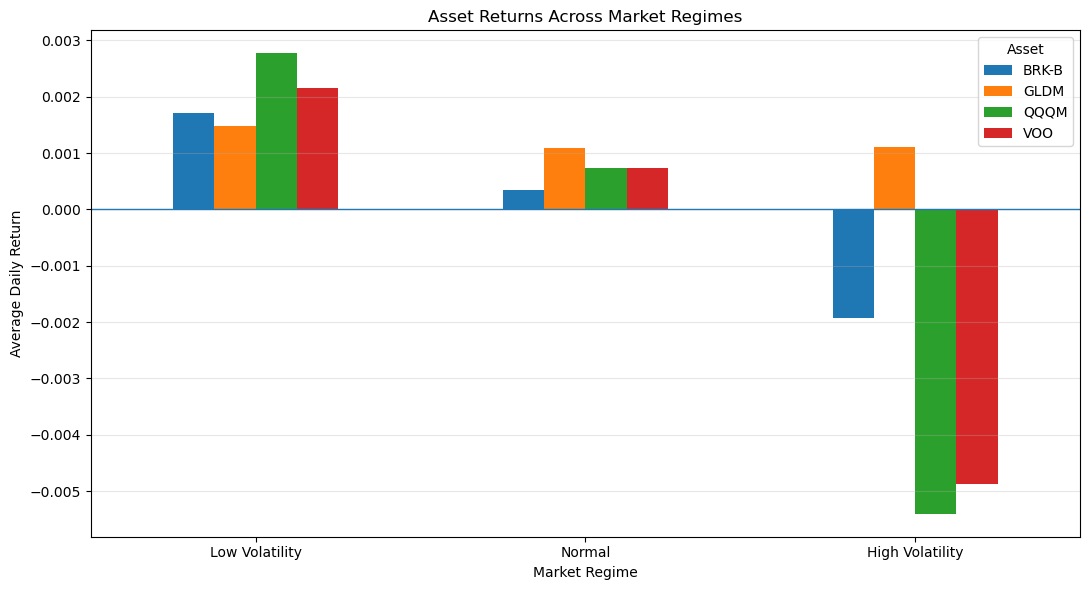

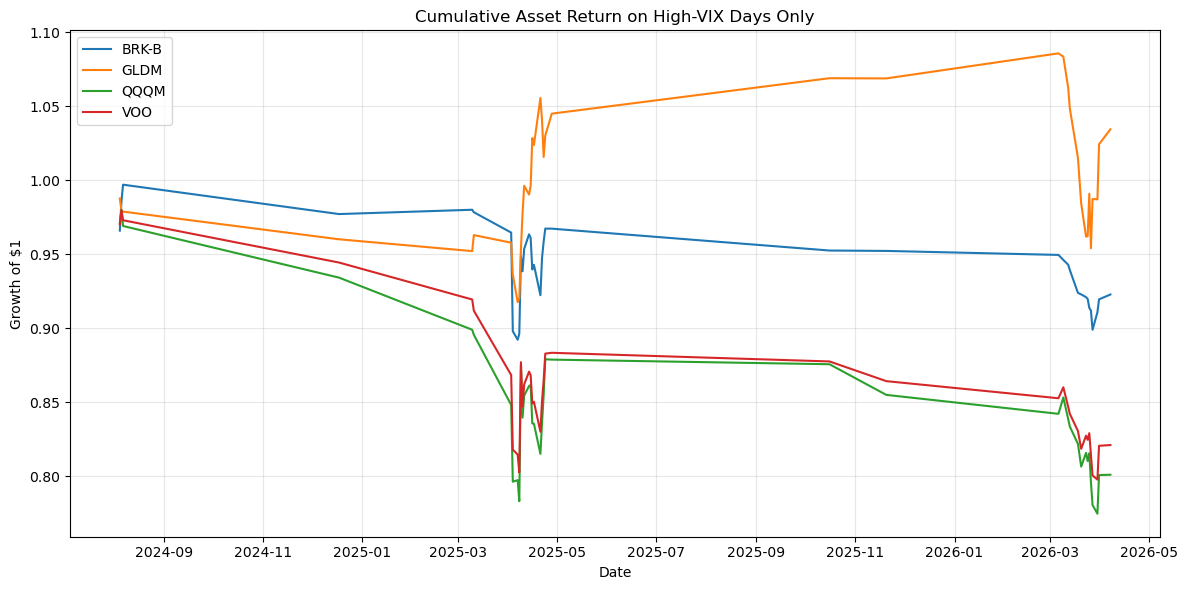


Asset Correlation During High-VIX Regime:


Ticker,BRK-B,GLDM,QQQM,VOO
Ticker,,,,
BRK-B,1.00,0.18,0.80,0.84
GLDM,0.18,1.00,0.30,0.29
QQQM,0.80,0.30,1.00,0.99
VOO,0.84,0.29,0.99,1.00



High-VIX Correlation with VOO:


,Correlation with VOO
Ticker,
GLDM,0.29
BRK-B,0.84
QQQM,0.99



High-VIX Defensive Characteristics:


,High-VIX Return,Correlation with VOO,Return Advantage vs VOO
Ticker,,,
GLDM,0.110%,0.29,+0.598%
BRK-B,-0.193%,0.84,+0.295%
VOO,-0.488%,1.00,+0.000%
QQQM,-0.540%,0.99,-0.052%


In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

assets_to_analyze = [
    "BRK-B",
    "GLDM",
    "QQQM",
    "VOO"
]

asset_returns_regime = (
    simple_returns[
        assets_to_analyze
    ]
    .reindex(
        regime_data.index
    )
)

asset_regime_data = (
    asset_returns_regime.copy()
)

asset_regime_data["VIX"] = (
    regime_data["VIX"]
)

asset_regime_data["Market Regime"] = (
    regime_data["Market Regime"]
)

def calculate_asset_metrics(return_series):

    r = return_series.dropna()

    n = len(r)

    if n < 2:

        return {
            "Average Daily Return": np.nan,
            "Annualized Volatility": np.nan,
            "Worst Day": np.nan,
            "Positive Day Ratio": np.nan,
            "Observations": n
        }

    average_daily_return = (
        r.mean()
    )

    annualized_volatility = (
        r.std()
        * np.sqrt(252)
    )

    worst_day = (
        r.min()
    )

    positive_day_ratio = (
        (r > 0).mean()
    )

    return {

        "Average Daily Return":
            average_daily_return,

        "Annualized Volatility":
            annualized_volatility,

        "Worst Day":
            worst_day,

        "Positive Day Ratio":
            positive_day_ratio,

        "Observations":
            n
    }

regime_order = [
    "Low Volatility",
    "Normal",
    "High Volatility"
]

asset_regime_results = []

for regime in regime_order:

    subset = (
        asset_regime_data[
            asset_regime_data[
                "Market Regime"
            ] == regime
        ]
    )

    for asset in assets_to_analyze:

        metrics = (
            calculate_asset_metrics(
                subset[asset]
            )
        )

        asset_regime_results.append({

            "Market Regime":
                regime,

            "Asset":
                asset,

            **metrics
        })

asset_regime_results_df = (
    pd.DataFrame(
        asset_regime_results
    )
)

print(
    "\nAsset Performance by Market Regime:"
)

display(

    asset_regime_results_df.style.format({

        "Average Daily Return":
            "{:.3%}",

        "Annualized Volatility":
            "{:.2%}",

        "Worst Day":
            "{:.2%}",

        "Positive Day Ratio":
            "{:.1%}",

        "Observations":
            "{:.0f}"
    })

)

return_pivot_assets = (

    asset_regime_results_df
    .pivot(
        index="Market Regime",
        columns="Asset",
        values="Average Daily Return"
    )
    .reindex(
        regime_order
    )
)

print(
    "\nAverage Daily Return by Regime:"
)

display(

    return_pivot_assets.style.format(
        "{:.3%}"
    )

)

vol_pivot_assets = (

    asset_regime_results_df
    .pivot(
        index="Market Regime",
        columns="Asset",
        values="Annualized Volatility"
    )
    .reindex(
        regime_order
    )
)

print(
    "\nAnnualized Volatility by Regime:"
)

display(

    vol_pivot_assets.style.format(
        "{:.2%}"
    )

)

high_vix_assets = (

    asset_regime_data[
        asset_regime_data[
            "Market Regime"
        ] == "High Volatility"
    ][assets_to_analyze]

)

print(
    "\nNumber of High-VIX Days:",
    len(high_vix_assets)
)

high_vix_summary = pd.DataFrame({

    "Average Daily Return":
        high_vix_assets.mean(),

    "Volatility":
        high_vix_assets.std()
        * np.sqrt(252),

    "Worst Day":
        high_vix_assets.min(),

    "Positive Day Ratio":
        (high_vix_assets > 0).mean()

})

high_vix_summary = (
    high_vix_summary
    .sort_values(
        "Average Daily Return",
        ascending=False
    )
)

print(
    "\nHigh-VIX Asset Summary:"
)

display(

    high_vix_summary.style.format({

        "Average Daily Return":
            "{:.3%}",

        "Volatility":
            "{:.2%}",

        "Worst Day":
            "{:.2%}",

        "Positive Day Ratio":
            "{:.1%}"
    })

)

high_vix_protection = (

    high_vix_assets.mean()
    - high_vix_assets["VOO"].mean()

)

high_vix_protection = (

    high_vix_protection
    .sort_values(
        ascending=False
    )

)

print(
    "\nHigh-VIX Protection Relative to VOO:"
)

display(

    high_vix_protection
    .to_frame(
        "Daily Return Advantage vs VOO"
    )
    .style.format(
        "{:+.3%}"
    )

)

return_pivot_assets.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.axhline(
    0,
    linewidth=1
)

plt.title(
    "Asset Returns Across Market Regimes"
)

plt.xlabel(
    "Market Regime"
)

plt.ylabel(
    "Average Daily Return"
)

plt.xticks(
    rotation=0
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.show()

if len(high_vix_assets) > 0:

    high_vix_growth = (

        1
        + high_vix_assets

    ).cumprod()

    plt.figure(
        figsize=(12, 6)
    )

    for asset in assets_to_analyze:

        plt.plot(
            high_vix_growth.index,
            high_vix_growth[asset],
            label=asset
        )

    plt.title(
        "Cumulative Asset Return on High-VIX Days Only"
    )

    plt.xlabel(
        "Date"
    )

    plt.ylabel(
        "Growth of $1"
    )

    plt.legend()

    plt.grid(
        alpha=0.3
    )

    plt.tight_layout()

    plt.show()

high_vix_corr = (
    high_vix_assets.corr()
)

print(
    "\nAsset Correlation During High-VIX Regime:"
)

display(

    high_vix_corr.style.format(
        "{:.2f}"
    )

)

diversification_vs_voo = (

    high_vix_corr["VOO"]
    .drop("VOO")
    .sort_values()

)

print(
    "\nHigh-VIX Correlation with VOO:"
)

display(

    diversification_vs_voo
    .to_frame(
        "Correlation with VOO"
    )
    .style.format(
        "{:.2f}"
    )

)

conclusion_table = pd.DataFrame({

    "High-VIX Return":
        high_vix_assets.mean(),

    "Correlation with VOO":
        high_vix_corr["VOO"],

    "Return Advantage vs VOO":
        high_vix_protection

})

conclusion_table = (
    conclusion_table
    .sort_values(
        "Return Advantage vs VOO",
        ascending=False
    )
)

print(
    "\nHigh-VIX Defensive Characteristics:"
)

display(

    conclusion_table.style.format({

        "High-VIX Return":
            "{:.3%}",

        "Correlation with VOO":
            "{:.2f}",

        "Return Advantage vs VOO":
            "{:+.3%}"
    })

)

## 10. Portfolio Return Attribution

The final step is to identify which assets actually drive portfolio performance.

Strong performance by an individual asset does not necessarily imply a large portfolio impact because the effect also depends on its portfolio weight.

The return contribution of asset $i$ at time $t$ is:

$$
C_{i,t}
=
w_{i,t}R_{i,t}
$$

Total portfolio return can therefore be expressed as:

$$
R_{p,t}
=
\sum_{i=1}^{N}
w_{i,t}R_{i,t}
$$

Using the 2-Year MVO strategy, portfolio returns are decomposed into contributions from BRK-B, GLDM, QQQM, and VOO.

The attribution analysis is used to determine which assets contribute positively or negatively to portfolio performance across different market regimes, with particular attention to high-volatility periods.


2-Year MVO Weight History:


Ticker,BRK-B,GLDM,QQQM,VOO
2022-12-30 00:00:00,35.00%,30.00%,0.00%,35.00%
2023-12-29 00:00:00,35.00%,35.00%,0.00%,30.00%
2024-12-31 00:00:00,30.00%,35.00%,35.00%,0.00%
2025-12-31 00:00:00,30.00%,35.00%,0.00%,35.00%



Attribution Reconstruction Check:
Average absolute difference: 4.4612069668054765e-06
Maximum absolute difference: 0.0018994513126656732
Mean difference: -1.1584714730340287e-06

Average Daily Return Contribution by Regime:


Ticker,BRK-B,GLDM,QQQM,VOO
Market Regime,,,,
Low Volatility,+0.059%,+0.052%,+0.012%,+0.055%
Normal,+0.011%,+0.038%,+0.017%,+0.011%
High Volatility,-0.061%,+0.038%,-0.069%,-0.091%



Sum of Daily Contributions by Regime:


...

,Absolute Contribution Share
Ticker,
GLDM,35.7%
QQQM,28.6%
BRK-B,23.3%
VOO,12.4%



Average Portfolio Weights by Market Regime:


Ticker,BRK-B,GLDM,QQQM,VOO
Market Regime,,,,
Low Volatility,33.96%,35.00%,4.33%,26.71%
Normal,31.15%,35.00%,15.83%,18.02%
High Volatility,30.53%,35.00%,18.42%,16.05%



High-VIX Portfolio Attribution Summary:


,Average Weight,Average Asset Return,Average Portfolio Contribution,Weight × Return Check
Ticker,,,,
GLDM,35.00%,+0.110%,+0.038%,+0.038%
BRK-B,30.53%,-0.193%,-0.061%,-0.059%
QQQM,18.42%,-0.540%,-0.069%,-0.099%
VOO,16.05%,-0.488%,-0.091%,-0.078%


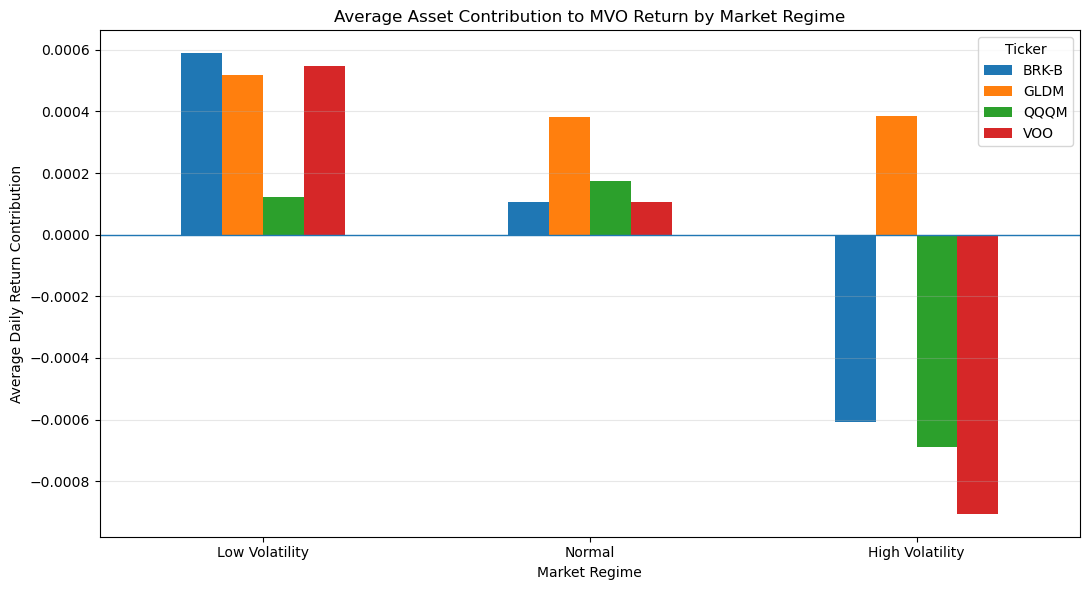

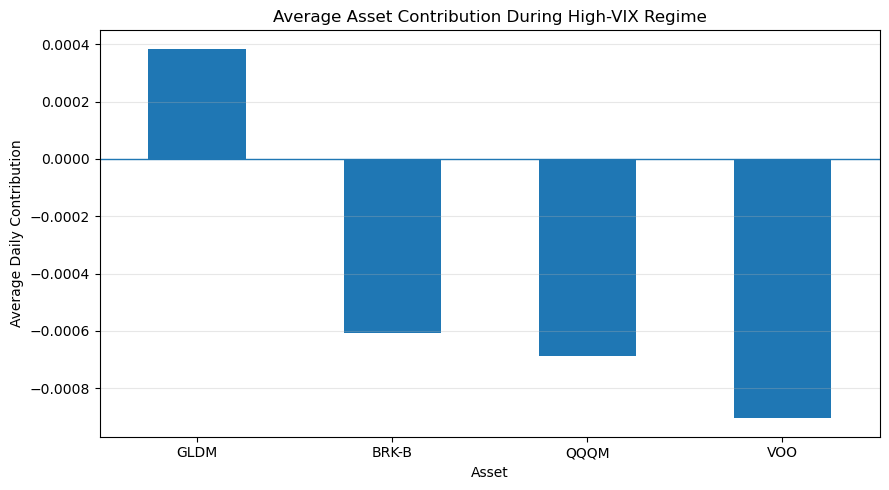

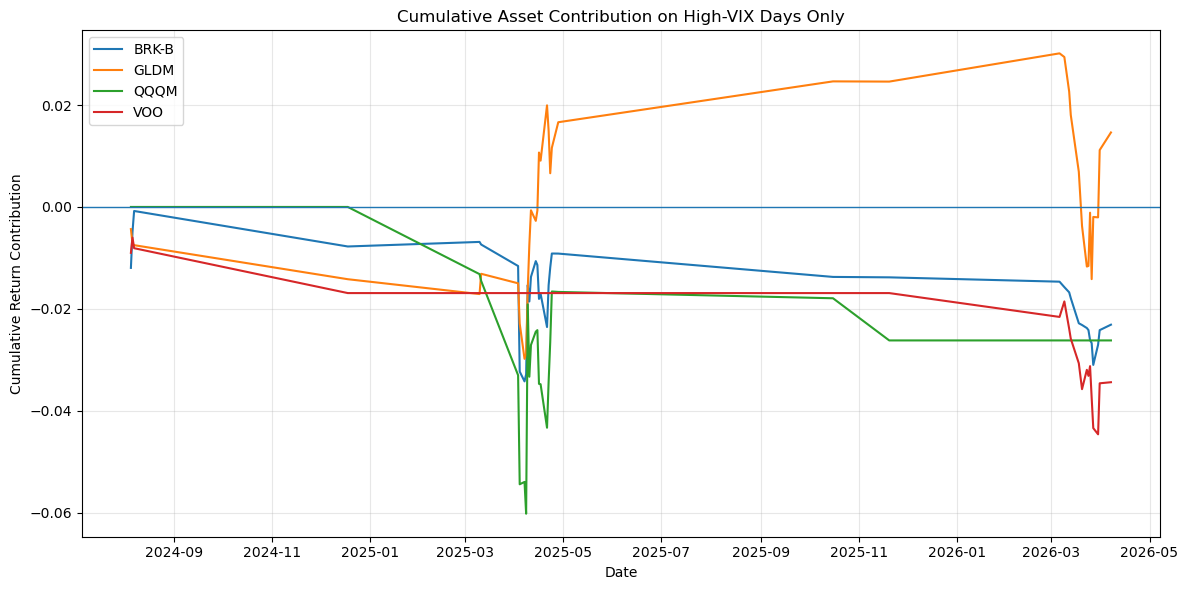


Simple Interpretation:
Best average High-VIX contributor: GLDM
Weakest average High-VIX contributor: VOO


In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

assets_attribution = [
    "BRK-B",
    "GLDM",
    "QQQM",
    "VOO"
]

weight_history_2y = (
    weight_results["2-Year MVO"]
    .copy()
)

weight_history_2y.index = pd.to_datetime(
    weight_history_2y.index
)

weight_history_2y = (
    weight_history_2y[
        assets_attribution
    ]
    .sort_index()
)

print(
    "\n2-Year MVO Weight History:"
)

display(
    weight_history_2y.style.format(
        "{:.2%}"
    )
)

daily_weights = (
    weight_history_2y
    .reindex(
        simple_returns.index
    )
    .ffill()
)

daily_weights = (
    daily_weights
    .reindex(
        regime_data.index
    )
)

asset_returns_for_attribution = (
    simple_returns[
        assets_attribution
    ]
    .reindex(
        regime_data.index
    )
)

valid_dates = (
    daily_weights
    .dropna()
    .index
)

daily_weights = (
    daily_weights
    .loc[
        valid_dates
    ]
)

asset_returns_for_attribution = (
    asset_returns_for_attribution
    .loc[
        valid_dates
    ]
)

attribution_regime = (
    regime_data
    .loc[
        valid_dates,
        "Market Regime"
    ]
)

daily_asset_contributions = (
    daily_weights
    * asset_returns_for_attribution
)

reconstructed_mvo_return = (
    daily_asset_contributions[
        assets_attribution
    ]
    .sum(
        axis=1
    )
)

actual_mvo_return = (
    comparison_returns[
        "2-Year MVO"
    ]
    .reindex(
        reconstructed_mvo_return.index
    )
)

reconstruction_difference = (
    reconstructed_mvo_return
    - actual_mvo_return
)

print(
    "\nAttribution Reconstruction Check:"
)

print(
    "Average absolute difference:",
    reconstruction_difference
    .abs()
    .mean()
)

print(
    "Maximum absolute difference:",
    reconstruction_difference
    .abs()
    .max()
)

print(
    "Mean difference:",
    reconstruction_difference
    .mean()
)

daily_contributions = (
    daily_asset_contributions.copy()
)

daily_contributions[
    "Reconstructed MVO"
] = reconstructed_mvo_return

daily_contributions[
    "Actual 2-Year MVO"
] = actual_mvo_return

daily_contributions[
    "Difference"
] = reconstruction_difference

daily_contributions[
    "Market Regime"
] = attribution_regime

regime_order = [
    "Low Volatility",
    "Normal",
    "High Volatility"
]

average_regime_contribution = (
    daily_contributions
    .groupby(
        "Market Regime"
    )[
        assets_attribution
    ]
    .mean()
    .reindex(
        regime_order
    )
)

print(
    "\nAverage Daily Return Contribution by Regime:"
)

display(
    average_regime_contribution
    .style
    .format(
        "{:+.3%}"
    )
)

sum_regime_contribution = (
    daily_contributions
    .groupby(
        "Market Regime"
    )[
        assets_attribution
    ]
    .sum()
    .reindex(
        regime_order
    )
)

print(
    "\nSum of Daily Contributions by Regime:"
)

display(
    sum_regime_contribution
    .style
    .format(
        "{:+.2%}"
    )
)

high_vix_contribution = (
    daily_contributions[
        daily_contributions[
            "Market Regime"
        ] == "High Volatility"
    ][
        assets_attribution
    ]
)

print(
    "\nNumber of High-VIX Attribution Days:",
    len(high_vix_contribution)
)

high_vix_average_contribution = (
    high_vix_contribution
    .mean()
    .sort_values(
        ascending=False
    )
)

print(
    "\nAverage Daily Contribution During High-VIX:"
)

display(
    high_vix_average_contribution
    .to_frame(
        "Average Daily Contribution"
    )
    .style
    .format(
        "{:+.3%}"
    )
)

high_vix_total_contribution = (
    high_vix_contribution
    .sum()
    .sort_values(
        ascending=False
    )
)

print(
    "\nTotal Contribution During High-VIX Days:"
)

display(
    high_vix_total_contribution
    .to_frame(
        "Total Contribution"
    )
    .style
    .format(
        "{:+.2%}"
    )
)

high_vix_absolute_contribution = (
    high_vix_contribution
    .abs()
    .sum()
)

high_vix_absolute_share = (
    high_vix_absolute_contribution
    /
    high_vix_absolute_contribution.sum()
)

high_vix_absolute_share = (
    high_vix_absolute_share
    .sort_values(
        ascending=False
    )
)

print(
    "\nShare of Absolute Portfolio Contribution During High-VIX:"
)

display(
    high_vix_absolute_share
    .to_frame(
        "Absolute Contribution Share"
    )
    .style
    .format(
        "{:.1%}"
    )
)

weight_regime_data = (
    daily_weights.copy()
)

weight_regime_data[
    "Market Regime"
] = attribution_regime

average_weights_by_regime = (
    weight_regime_data
    .groupby(
        "Market Regime"
    )[
        assets_attribution
    ]
    .mean()
    .reindex(
        regime_order
    )
)

print(
    "\nAverage Portfolio Weights by Market Regime:"
)

display(
    average_weights_by_regime
    .style
    .format(
        "{:.2%}"
    )
)

if "high_vix_assets" in globals():

    high_vix_asset_returns = (
        high_vix_assets
        .mean()
    )

else:

    high_vix_asset_returns = (
        asset_returns_for_attribution[
            attribution_regime
            == "High Volatility"
        ]
        .mean()
    )

high_vix_weights = (
    average_weights_by_regime
    .loc[
        "High Volatility"
    ]
)

final_attribution_summary = pd.DataFrame({

    "Average Weight":
        high_vix_weights,

    "Average Asset Return":
        high_vix_asset_returns,

    "Average Portfolio Contribution":
        high_vix_average_contribution

})

final_attribution_summary[
    "Weight × Return Check"
] = (

    final_attribution_summary[
        "Average Weight"
    ]

    *

    final_attribution_summary[
        "Average Asset Return"
    ]

)

final_attribution_summary = (
    final_attribution_summary
    .sort_values(
        "Average Portfolio Contribution",
        ascending=False
    )
)

print(
    "\nHigh-VIX Portfolio Attribution Summary:"
)

display(
    final_attribution_summary
    .style
    .format({

        "Average Weight":
            "{:.2%}",

        "Average Asset Return":
            "{:+.3%}",

        "Average Portfolio Contribution":
            "{:+.3%}",

        "Weight × Return Check":
            "{:+.3%}"
    })
)

average_regime_contribution.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.axhline(
    0,
    linewidth=1
)

plt.title(
    "Average Asset Contribution to MVO Return by Market Regime"
)

plt.xlabel(
    "Market Regime"
)

plt.ylabel(
    "Average Daily Return Contribution"
)

plt.xticks(
    rotation=0
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.show()

high_vix_average_contribution.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.axhline(
    0,
    linewidth=1
)

plt.title(
    "Average Asset Contribution During High-VIX Regime"
)

plt.xlabel(
    "Asset"
)

plt.ylabel(
    "Average Daily Contribution"
)

plt.xticks(
    rotation=0
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.show()

if len(high_vix_contribution) > 0:

    cumulative_high_vix_contribution = (
        high_vix_contribution
        .cumsum()
    )

    plt.figure(
        figsize=(12, 6)
    )

    for asset in assets_attribution:

        plt.plot(
            cumulative_high_vix_contribution.index,
            cumulative_high_vix_contribution[
                asset
            ],
            label=asset
        )

    plt.axhline(
        0,
        linewidth=1
    )

    plt.title(
        "Cumulative Asset Contribution on High-VIX Days Only"
    )

    plt.xlabel(
        "Date"
    )

    plt.ylabel(
        "Cumulative Return Contribution"
    )

    plt.legend()

    plt.grid(
        alpha=0.3
    )

    plt.tight_layout()

    plt.show()

best_contributor = (
    high_vix_average_contribution
    .idxmax()
)

worst_contributor = (
    high_vix_average_contribution
    .idxmin()
)

print(
    "\nSimple Interpretation:"
)

print(
    f"Best average High-VIX contributor: "
    f"{best_contributor}"
)

print(
    f"Weakest average High-VIX contributor: "
    f"{worst_contributor}"
)